In [1]:
import pandas as pd
from pyfaidx import Fasta
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from Bio.Seq import Seq

In [2]:
# load circRbase references
circids_df = pd.read_csv('/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/exoRase/circRNAs_anno.csv', usecols = ['circID', 'circBase ID', 'Genomic position', 'Strand'])
circids_df

,circID,circBase ID,Genomic position,Strand
0,exo_circ_000001,NaN,chr1:90726-289370,-
1,exo_circ_000002,NaN,chr1:139790-739024,-
2,exo_circ_000003,NaN,chr1:522859-810170,-
3,exo_circ_000004,NaN,chr1:629113-629265,-
4,exo_circ_000005,NaN,chr1:629113-629271,-
...,...,...,...,...
126811,exo_circ_126812,NaN,chrY:57082143-57106400,+
126812,exo_circ_126813,NaN,chrY:57084632-57087107,+
126813,exo_circ_126814,NaN,chrY:57084632-57106400,+
126814,exo_circ_126815,NaN,chrY:57129867-57130043,-


In [3]:
circids_df['circBase ID'].isnull().sum()

107660

In [4]:
# load circRbase BRCA EV circRNAs
EV_BRCA_df = pd.read_csv('/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/exoRase/EVPs_in_BRCA_circRNAs.txt', sep = '	')
EV_BRCA_df['sum_EVP'] = EV_BRCA_df.iloc[:, 1:].sum(axis=1)
EV_BRCA_df

,circID,EVPs in BRCA01,EVPs in BRCA02,EVPs in BRCA03,EVPs in BRCA04,EVPs in BRCA05,EVPs in BRCA06,EVPs in BRCA07,EVPs in BRCA08,EVPs in BRCA09,...,EVPs in BRCA234,EVPs in BRCA235,EVPs in BRCA236,EVPs in BRCA237,EVPs in BRCA238,EVPs in BRCA239,EVPs in BRCA240,EVPs in BRCA241,EVPs in BRCA242,sum_EVP
0,exo_circ_000001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,exo_circ_000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,exo_circ_000003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,exo_circ_000004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,exo_circ_000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126811,exo_circ_126812,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,0,0,47
126812,exo_circ_126813,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
126813,exo_circ_126814,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,16,51
126814,exo_circ_126815,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
EV_BRCA_df['Genomic position'] = circids_df['Genomic position'].values
EV_BRCA_df['Strand'] = circids_df['Strand'].values
EV_BRCA_df

,circID,EVPs in BRCA01,EVPs in BRCA02,EVPs in BRCA03,EVPs in BRCA04,EVPs in BRCA05,EVPs in BRCA06,EVPs in BRCA07,EVPs in BRCA08,EVPs in BRCA09,...,EVPs in BRCA236,EVPs in BRCA237,EVPs in BRCA238,EVPs in BRCA239,EVPs in BRCA240,EVPs in BRCA241,EVPs in BRCA242,sum_EVP,Genomic position,Strand
0,exo_circ_000001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chr1:90726-289370,-
1,exo_circ_000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chr1:139790-739024,-
2,exo_circ_000003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chr1:522859-810170,-
3,exo_circ_000004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chr1:629113-629265,-
4,exo_circ_000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chr1:629113-629271,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126811,exo_circ_126812,0,0,0,0,0,0,0,0,0,...,0,4,0,0,0,0,0,47,chrY:57082143-57106400,+
126812,exo_circ_126813,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,chrY:57084632-57087107,+
126813,exo_circ_126814,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,16,51,chrY:57084632-57106400,+
126814,exo_circ_126815,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,chrY:57129867-57130043,-


In [6]:
EV_BRCA_df = EV_BRCA_df[['circID', 'sum_EVP', 'Genomic position', 'Strand']]

# 去除 sum_EVP 等于 0 的行
EV_BRCA_df = EV_BRCA_df[EV_BRCA_df['sum_EVP'] != 0]

print(len(EV_BRCA_df))
print(EV_BRCA_df.head())

86405
             circID  sum_EVP    Genomic position Strand
5   exo_circ_000006       10  chr1:629163-629337      -
15  exo_circ_000016        1  chr1:629190-629422      -
21  exo_circ_000022        2  chr1:629265-629422      -
22  exo_circ_000023        1  chr1:629270-629422      -
25  exo_circ_000026       18  chr1:629277-629422      -


In [7]:
# load bed reference
bed_df = pd.read_csv('/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/circAtlas/human_bed_v3.0.txt', sep = '	')

bed_df


,Chro,Start,End,Strand,circAltas_ID
0,KI270742.1,1326,34982,-,hsa-intergenic_003508
1,chr1,805799,810170,-,hsa-RP11-206L10_0001
2,chr1,808574,810170,-,hsa-RP11-206L10_0002
3,chr1,926703,927095,-,hsa-SAMD11_0013
4,chr1,935772,939412,+,hsa-SAMD11_0001
...,...,...,...,...,...
768981,chr9,125001983,125003570,-,hsa-SCAI_0155
768982,chr9,131474454,131478619,+,hsa-PRRC2B_0178
768983,chr9,136383953,136384814,-,hsa-SNAPC4_0028
768984,chrX,45037655,45051802,+,hsa-KDM6A_0171


In [8]:
bed_df['circAltas_ID'].isnull().sum()

0

In [9]:
# 1. 从 Genomic position 中提取 Chro, Start, End
EV_BRCA_df[['Chro', 'Pos']] = EV_BRCA_df['Genomic position'].str.split(':', expand=True)
EV_BRCA_df[['Start', 'End']] = EV_BRCA_df['Pos'].str.split('-', expand=True)

# 转换数据类型以便进行数值比较
EV_BRCA_df['Start'] = EV_BRCA_df['Start'].astype(int)
EV_BRCA_df['End'] = EV_BRCA_df['End'].astype(int)
bed_df['Start'] = bed_df['Start'].astype(int)
bed_df['End'] = bed_df['End'].astype(int)

# 2 & 3. 优化匹配逻辑：仅遍历容差范围内所有的精确组合 (-1, 0, 1)，避免笛卡尔积导致内存爆炸
matched_chunks = []
for d_start in [-1, 0, 1]:
    for d_end in [-1, 0, 1]:
        temp_ev = EV_BRCA_df.copy()
        # 加上偏移量，去凑 bed_df 的精确坐标
        temp_ev['Start_match'] = temp_ev['Start'] + d_start
        temp_ev['End_match'] = temp_ev['End'] + d_end
        
        # 使用多列进行精确匹配合并
        chunk = pd.merge(
            temp_ev, 
            bed_df, 
            left_on=['Chro', 'Strand', 'Start_match', 'End_match'], 
            right_on=['Chro', 'Strand', 'Start', 'End'],
            suffixes=('_ev', '_bed')
        )
        matched_chunks.append(chunk)

# 将所有可能的匹配组合归拢，并去重
matched_df = pd.concat(matched_chunks, ignore_index=True)
matched_df = matched_df.drop_duplicates(subset=['circID', 'circAltas_ID'])

# 4. 将匹配到的 circAltas_ID 提取为级别格式（用逗号分隔所有匹配到的 ID）
mapped_results = matched_df.groupby('circID')['circAltas_ID'].apply(lambda x: ','.join(x.unique())).reset_index()

# 5. 统计找到了多少个不重复的 circAltas_ID
total_unique_circaltas = matched_df['circAltas_ID'].nunique()
total_matches = len(matched_df)

print(f"总共成功匹配了 {total_matches} 条记录。")
print(f"共找到了 {total_unique_circaltas} 个不重复的 circAltas_ID。")

# 将匹配到的结果存放在全新的 DataFrame 中
mapped_circ_df = mapped_results.rename(columns={'circAltas_ID': 'matched_circAltas_IDs'})

# 增加功能：将 EV_BRCA_df 的 sum_EVP 列保留添加到 mapped_circ_df 中
mapped_circ_df = mapped_circ_df.merge(EV_BRCA_df[['circID', 'sum_EVP']].drop_duplicates(), on='circID', how='left')

mapped_circ_df

总共成功匹配了 77249 条记录。
共找到了 77249 个不重复的 circAltas_ID。


,circID,matched_circAltas_IDs,sum_EVP
0,exo_circ_000216,hsa-MTATP6P1_0003,1
1,exo_circ_000253,hsa-MTATP6P1_0009,18
2,exo_circ_000254,hsa-MTATP6P1_0002,226
3,exo_circ_000310,hsa-MTATP6P1_0011,1
4,exo_circ_000327,hsa-MTATP6P1_0012,3
...,...,...,...
77228,exo_circ_126503,hsa-TMLHE-AS1_0024,15
77229,exo_circ_126592,hsa-ZFY_0001,21
77230,exo_circ_126758,hsa-TTTY14_0003,8
77231,exo_circ_126785,hsa-TXLNGY_0002,17


In [10]:
seq_df = pd.read_csv('/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/circAtlas/human_sequence_v3.0', sep = ' ', header=None, names=['circAltas_ID', 'Sequence'])
seq_df

,circAltas_ID,Sequence
0,hsa-intergenic_003508,unknown
1,hsa-RP11-206L10_0001,TATCTTAAATAGTGAAGATGGAGAAATAGTCAATAATGAAGAGCAT...
2,hsa-RP11-206L10_0002,TATCTTAAATAGTGAAGATGGAGAAATAGTCAATAATGAAGAGCAT...
3,hsa-SAMD11_0013,GTGCGGCTGTGTCCCCTTCCCCTGCCCAACATGCTGTATGTCTGAG...
4,hsa-SAMD11_0001,CCAGGACGGCAACCTTCCCACCCTCATATCCAGCGTCCACCGCAGC...
...,...,...
768981,hsa-SCAI_0155,GTTAAGGAGCTGCCTGCCAATAGCGTGCTTCTGATTTACCTGTCGG...
768982,hsa-PRRC2B_0178,unknown
768983,hsa-SNAPC4_0028,GTATCTCAGGAGATTACATTTCAGCTTGAAAAAGGGTCGGTGGAAT...
768984,hsa-KDM6A_0171,TTCAATTTCACATTGCCCACTTATATGAAACCCAGAGGAAATATCA...


In [11]:
temp_df = mapped_circ_df.copy()
temp_df['single_ID'] = temp_df['matched_circAltas_IDs'].str.split(',')
temp_df = temp_df.explode('single_ID')

# 与 seq_df 进行合并，提取 Sequence
merged_seq = pd.merge(temp_df, seq_df, left_on='single_ID', right_on='circAltas_ID', how='left')

# 将提取到的 Sequence 按 circID 进行聚合（若有多个序列用逗号分隔）
seq_agg = merged_seq.groupby('circID')['Sequence'].apply(lambda x: ','.join(x.dropna().astype(str))).reset_index()

# 将提取合并后的 Sequence 列合并回原始的 mapped_circ_df 中
mapped_circ_df = pd.merge(mapped_circ_df, seq_agg, on='circID', how='left')

mapped_circ_df

,circID,matched_circAltas_IDs,sum_EVP,Sequence
0,exo_circ_000216,hsa-MTATP6P1_0003,1,GTGTGCCTTGTGGTAAGAAGTGGGCTAGGGCATTTTTAATCTTAGA...
1,exo_circ_000253,hsa-MTATP6P1_0009,18,GTGTGCCTTGTGGTAAGAAGTGGGCTAGGGCATTTTTAATCTTAGA...
2,exo_circ_000254,hsa-MTATP6P1_0002,226,GGGTGTAGGTGTGCCTTGTGGTAAGAAGTGGGCTAGGGCATTTTTA...
3,exo_circ_000310,hsa-MTATP6P1_0011,1,GCTGATGGTTTCGATAATAACTAGTATAGGGATAAGGGGTGTAGGT...
4,exo_circ_000327,hsa-MTATP6P1_0012,3,GCTGATGGTTTCGATAATAACTAGTATAGGGATAAGGGGTGTAGGT...
...,...,...,...,...
77228,exo_circ_126503,hsa-TMLHE-AS1_0024,15,ATCAGTTAAGCAAAGGAAACAGAAGTACATGTGTATGTACAC
77229,exo_circ_126592,hsa-ZFY_0001,21,GAGCTGTGACTAATGAGAATTAAAGGCCATGGATGAAGATGAATTT...
77230,exo_circ_126758,hsa-TTTY14_0003,8,AACTGTCCATTTGGCTATGAGCGAATCATCCTGCTTGCTTTTATAA...
77231,exo_circ_126785,hsa-TXLNGY_0002,17,TTTGTGAATAGCACAATGGAAGAAGCTGGACTTTGTGGGTTAAGAG...


In [12]:
EV_BRCA_df = mapped_circ_df

# 1. 记录清洗前的原始行数
original_row_count_ev = len(EV_BRCA_df)

# 2. 执行多条件过滤
# - 排除包含 'N' 或 'n' 的序列 (case=False)
# - 排除显式的 "Sequence_not_found" 标记
# - 排除空值 (NaN/None)
# - 排除空字符串 (len > 0)
EV_BRCA_df = EV_BRCA_df[
    (~EV_BRCA_df['Sequence'].str.contains('N', case=False, na=False)) & 
    (EV_BRCA_df['Sequence'] != "unknown") & 
    (EV_BRCA_df['Sequence'].notna()) &
    (EV_BRCA_df['Sequence'].str.len() > 0)
].copy()

# 3. 重置索引，确保索引连续
EV_BRCA_df = EV_BRCA_df.reset_index(drop=True)

# 4. 计算并统计结果
new_row_count_ev = len(EV_BRCA_df)
deleted_rows_ev = original_row_count_ev - new_row_count_ev

print("--- EV_BRCA_df 清洗报告 ---")
print(f"原始行数: {original_row_count_ev}")
print(f"删除行数: {deleted_rows_ev}")
print(f"剩余行数: {new_row_count_ev}")

--- EV_BRCA_df 清洗报告 ---
原始行数: 77233
删除行数: 1664
剩余行数: 75569


In [13]:
# 计算序列长度
EV_BRCA_df['Sequence_Length'] = EV_BRCA_df['Sequence'].str.len()
original_ev_count = len(EV_BRCA_df)

# 执行长度过滤（保留 <= 11238 bp 的行）
EV_BRCA_df = EV_BRCA_df[EV_BRCA_df['Sequence_Length'] <= 11238].copy()

# 统计并打印结果
deleted_ev = original_ev_count - len(EV_BRCA_df)
print(f"EV_BRCA_df 清洗完成：删除了 {deleted_ev} 条过长序列，剩余 {len(EV_BRCA_df)} 条。")

EV_BRCA_df 清洗完成：删除了 0 条过长序列，剩余 75569 条。


--- EV_BRCA_df 长度统计 ---
最短序列长度: 20
最长序列长度: 2971
平均序列长度: 330.23

序列长度分布（按分箱）：
20.0 - 118.4: 9153 条序列
118.4 - 216.7: 16492 条序列
216.7 - 315.1: 16984 条序列
315.1 - 413.5: 13155 条序列
413.5 - 511.8: 8827 条序列
511.8 - 610.2: 4641 条序列
610.2 - 708.6: 2360 条序列
708.6 - 806.9: 1252 条序列
806.9 - 905.3: 798 条序列
905.3 - 1003.7: 507 条序列
1003.7 - 1102.0: 329 条序列
1102.0 - 1200.4: 242 条序列
1200.4 - 1298.8: 183 条序列
1298.8 - 1397.1: 143 条序列
1397.1 - 1495.5: 115 条序列
1495.5 - 1593.9: 110 条序列
1593.9 - 1692.2: 92 条序列
1692.2 - 1790.6: 60 条序列
1790.6 - 1889.0: 65 条序列
1889.0 - 1987.3: 53 条序列
1987.3 - 2085.7: 7 条序列
2085.7 - 2184.1: 0 条序列
2184.1 - 2282.4: 0 条序列
2282.4 - 2380.8: 0 条序列
2380.8 - 2479.2: 0 条序列
2479.2 - 2577.5: 0 条序列
2577.5 - 2675.9: 0 条序列
2675.9 - 2774.3: 0 条序列
2774.3 - 2872.6: 0 条序列
2872.6 - 2971.0: 1 条序列


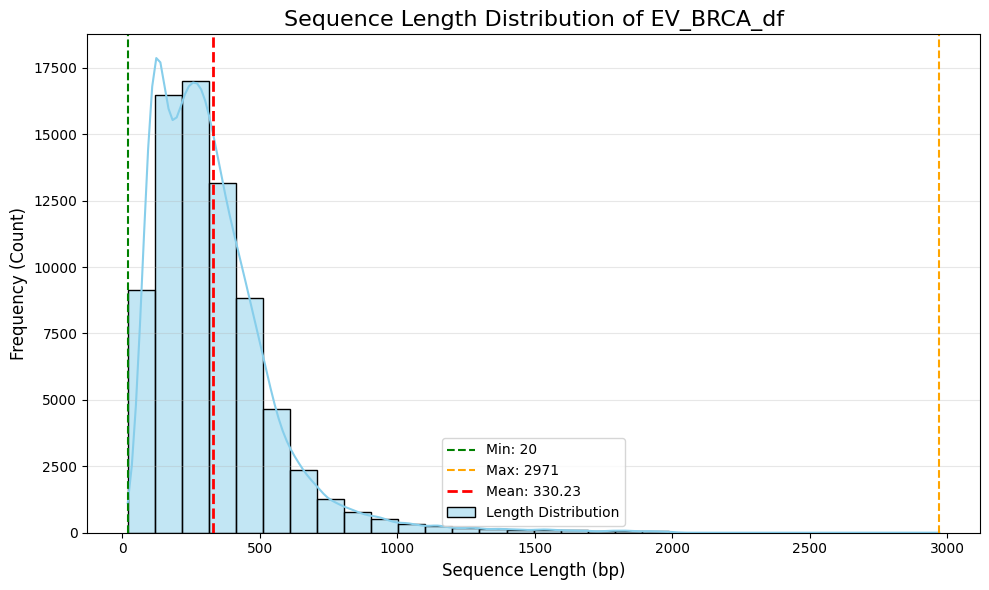

In [14]:
# 1. 基础统计量计算
max_length = EV_BRCA_df['Sequence_Length'].max()
min_length = EV_BRCA_df['Sequence_Length'].min()
average_length = EV_BRCA_df['Sequence_Length'].mean()

print(f"--- EV_BRCA_df 长度统计 ---")
print(f"最短序列长度: {min_length}")
print(f"最长序列长度: {max_length}")
print(f"平均序列长度: {average_length:.2f}")

# 2. 设置分箱区间并打印分布详情
bins = np.histogram_bin_edges(EV_BRCA_df['Sequence_Length'], bins=30)
bin_counts, bin_edges = np.histogram(EV_BRCA_df['Sequence_Length'], bins=bins)

print("\n序列长度分布（按分箱）：")
for i in range(len(bin_counts)):
    print(f"{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}: {bin_counts[i]} 条序列")

# 3. 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(EV_BRCA_df['Sequence_Length'], bins=bins, kde=True, color='skyblue', label='Length Distribution')

# 4. 添加最小值、最大值和平均值的垂直标注线
plt.axvline(min_length, color='green', linestyle='--', linewidth=1.5, label=f'Min: {min_length}')
plt.axvline(max_length, color='orange', linestyle='--', linewidth=1.5, label=f'Max: {max_length}')
plt.axvline(average_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {average_length:.2f}')

# 5. 图形细节美化
plt.title('Sequence Length Distribution of EV_BRCA_df', fontsize=16)
plt.xlabel('Sequence Length (bp)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 6. 展示图形
plt.show()

In [ ]:

stats = EV_BRCA_df['sum_EVP'].describe()
print(stats)

count     75569.000000
mean        348.912358
std        2697.373569
min           1.000000
25%          16.000000
50%          53.000000
75%         159.000000
max      287288.000000
Name: sum_EVP, dtype: float64


In [16]:
EV_BRCA_df.to_csv('./exoRbase_output.bak.csv')